In [1]:

# LabOne Q:
from laboneq.simple import *

# Helpers:
from laboneq.contrib.example_helpers.plotting.plot_helpers import plot_simulation

import matplotlib.pyplot as plt
import numpy as np
import laboneq
print(laboneq.__version__)
import numpy as np
import matplotlib.pyplot as plt
import time
# Use this if you need to reset
# session.devices[f"SHFQC_{serial_num}"].factory_reset()

2.57.0


In [2]:
"""Descriptor for a QCCS consisting of a single SHFQC
"""
descriptor_shfqc = """ 
instruments:
  SHFQC:
  - address: DEV12296
    uid: device_shfqc

connections:
  device_shfqc:
    - iq_signal: q0/drive_line
      ports: SGCHANNELS/0/OUTPUT
    - iq_signal: twpa/pump_line
      ports: SGCHANNELS/2/OUTPUT
    - iq_signal: q0/measure_line
      ports: [QACHANNELS/0/OUTPUT]
    - acquire_signal: q0/acquire_line
      ports: [QACHANNELS/0/INPUT]
"""
# Define and Load our Device Setup
device_setup = DeviceSetup.from_descriptor(
    descriptor_shfqc,
    server_host="127.0.0.1",  # ip address of the LabOne dataserver used to communicate with the instruments
    server_port="8004",  # port number of the dataserver - default is 8004
    setup_name="UCLA_SHFQC",  # setup name
)

# Are we emulating? or actually creating pulses?
emulate = True
# create and connect to session
session = Session(device_setup=device_setup)
session.connect(do_emulation=emulate)


[2025.08.18 14:34:50.480] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is /Users/runzhaoguo/Documents/MQST-UCLA/qubit_design/measurements/examples/laboneq_output/log
[2025.08.18 14:34:50.482] INFO    VERSION: laboneq 2.57.0
[2025.08.18 14:34:50.482] INFO    Connecting to data server at 127.0.0.1:8004
[2025.08.18 14:34:50.483] INFO    Connected to Zurich Instruments LabOne Data Server version 25.07.0.507 at 127.0.0.1:8004
[2025.08.18 14:34:50.484] INFO    Configuring the device setup
[2025.08.18 14:34:50.486] INFO    The device setup is configured


In [3]:
# define experiment
def resonator_spec_twpa(
    exp_id="resonator_spec_twpa_exp",
    average_exponent = 3,  # 2^n averages, maximum: n = 17. 
    acq_freq_sweep   = LinearSweepParameter(uid="acquisition_frequency_sweep", start=-600e6, stop=600e6, count=2001),
    acq_lo_sweep   = SweepParameter(uid="acquisition_lo_sweep", values=[3,4,5,6,7]),
    pump_amp = 0.5,
    integration_length = 2e-6,
):
    # Create Experiment
    exp = Experiment(
        uid = exp_id,
        signals = [
            # ExperimentSignal("qb_drive"),
            ExperimentSignal("twpa_pump"),
            ExperimentSignal("measure"),
            ExperimentSignal("acquire"),
        ],
    )
    # cw_pump_pulse  = pulse_library.const(uid="cw_pump_pulse", length=2e-6, amplitude=10**(-0.07875), can_compress=False,)
    cw_pump_pulse  = pulse_library.const(uid="cw_pump_pulse", amplitude=pump_amp, can_compress=False,)
    readout_pulse = pulse_library.const(uid="readout_pulse", amplitude=1.)

    # return exp
    with exp.sweep(uid ="acq_lo_sweep",parameter=acq_lo_sweep,):
        with exp.acquire_loop_rt(uid="spectro_loop", count=pow(2, average_exponent), 
                            acquisition_type=AcquisitionType.SPECTROSCOPY,
                            # averaging_mode=AveragingMode.SEQUENTIAL,
                            ):   
       
            with exp.sweep(uid="acq_freq_sweep", parameter=acq_freq_sweep,):
                with exp.section(uid="spectroscopy"):
                    exp.play(signal="measure", pulse=readout_pulse, length=integration_length),
                    exp.play(signal="twpa_pump", pulse=cw_pump_pulse, length=integration_length),
                    exp.acquire(signal="acquire", handle="res_spec", length=integration_length)
                    
                with exp.section(uid="relax", length=1e-6):
                    exp.play(signal="twpa_pump", pulse=cw_pump_pulse, length=1e-6)
                    exp.reserve("measure")
                    exp.reserve("acquire")    
                            
    return exp

In [4]:
[7.1491, 7.1815, 7.2066, 7.2306, 7.2623, 7.2908]

[7.1491, 7.1815, 7.2066, 7.2306, 7.2623, 7.2908]

In [5]:
pump_range = -25
pump_amp = 10**(-0.03)
# pump_amp = 0
pump_fre_lo  = 7.8e9
pump_fre= 7.9690e9 - pump_fre_lo
# acq_lo_sweep_range = np.array([5e9,6e9,7e9,8e9])
# acq_lo_sweep_range = np.array([5.6e9,6.6e9,7.6e9])
acq_lo_sweep_range = np.array([7.0e9])

# acq_res_fre = 7.1491e9 #Q0
# acq_res_fre = 7.1815e9 #Q1
# acq_res_fre = 7.2066e9 #Q2
# acq_res_fre = 7.2306e9 #Q3
acq_res_fre = 7.2623e9 #Q4
# acq_res_fre = 7.2908e9 #Q5

acq_fre_swp_st  = acq_res_fre-7e9-1e6
acq_fre_swp_end = acq_res_fre-7e9+1e6
# acq_fre_swp_st  = 7.2623e9-7e9-1e6
# acq_fre_swp_end = 7.2623e9-7e9+1e6
# acq_fre_swp_st  = -500e6
# acq_fre_swp_end = 500e6
acq_fre_swp_cnt = 501


acq_lo_sweep   = SweepParameter(uid="acquisition_lo_sweep", values=acq_lo_sweep_range ) 
acq_freq_sweep   = LinearSweepParameter(
    uid="acquisition_frequency_sweep", 
    start=acq_fre_swp_st, 
    stop=acq_fre_swp_end, 
    count=acq_fre_swp_cnt)

exp_resonator_spec_twpa = resonator_spec_twpa(
    average_exponent = 12,
    acq_lo_sweep = acq_lo_sweep,
    acq_freq_sweep = acq_freq_sweep,
    pump_amp= pump_amp,
    integration_length = 5e-6,
    )
print

<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [6]:
map_q0 = {}
# map_q0['qb_drive'] = device_setup.logical_signal_groups["q0"].logical_signals["drive_line"]
map_q0['twpa_pump'] = device_setup.logical_signal_groups["twpa"].logical_signals["pump_line"]
map_q0['measure'] = device_setup.logical_signal_groups["q0"].logical_signals["measure_line"]
map_q0['acquire'] = device_setup.logical_signal_groups["q0"].logical_signals["acquire_line"]
exp_resonator_spec_twpa.set_signal_map(map_q0)

In [7]:
exp_calibration = Calibration()

exp_calibration["twpa_pump"] = SignalCalibration(
    oscillator = Oscillator(uid = "twpa_pump_osc", frequency = pump_fre,
        modulation_type=ModulationType.HARDWARE
    ),
    local_oscillator = Oscillator(uid="twpa_lo", frequency = pump_fre_lo),
    range = pump_range,
)
exp_calibration["measure"] = SignalCalibration(
    oscillator = Oscillator(uid = "qa_osc_0", frequency = acq_freq_sweep,
        modulation_type=ModulationType.HARDWARE
    ),
    local_oscillator = Oscillator(uid="qa_lo", frequency = acq_lo_sweep),
    range = -30, amplitude= 0.1,
)
exp_calibration["acquire"] = SignalCalibration(
    range = -40, amplitude= 1,
)
exp_resonator_spec_twpa.set_calibration(exp_calibration)

In [8]:
compiled_resonator_spec_twpa = session.compile(exp_resonator_spec_twpa)

[2025.08.18 14:34:50.514] INFO    Starting LabOne Q Compiler run...
[2025.08.18 14:34:50.542] INFO    Schedule completed. [0.026 s]
[2025.08.18 14:34:50.619] INFO    Code generation completed for all AWGs. [0.076 s]
[2025.08.18 14:34:50.619] INFO    Completed compilation step 1 of 1. [0.103 s]
[2025.08.18 14:34:50.620] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.18 14:34:50.621] INFO      Device            AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2025.08.18 14:34:50.621] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.18 14:34:50.621] INFO      device_shfqc        0         21            0           1     20000  
[2025.08.18 14:34:50.621] INFO      device_shfqc_sg     2         17            3           2     24000  
[2025.08.18 14:34:50.621] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.18 14:34:50.622] INFO      TOTAL                         38 

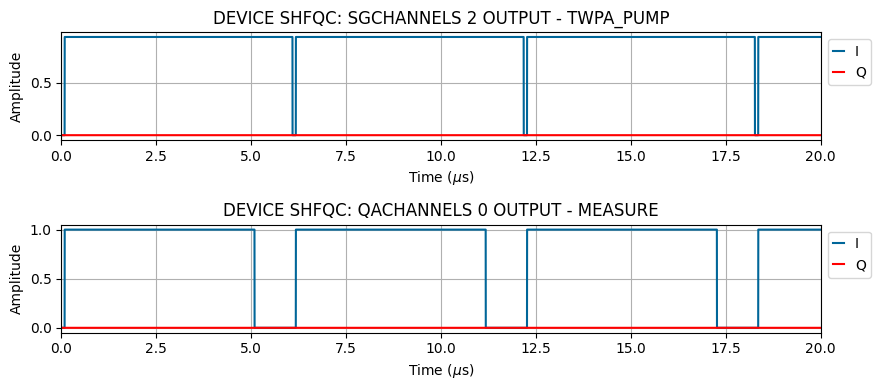

In [9]:
plot_simulation(compiled_resonator_spec_twpa, 0, 20e-6)

In [10]:
# session.devices["device_shfqc"].factory_reset()
# time.sleep(0.1)

In [11]:
run_resonator_spec_twpa = session.run(compiled_resonator_spec_twpa)

[2025.08.18 14:34:50.828] INFO    Starting near-time execution...
[2025.08.18 14:34:50.831] INFO    Estimated RT execution time: 12.49 s.
[2025.08.18 14:34:50.832] INFO    Finished near-time execution.


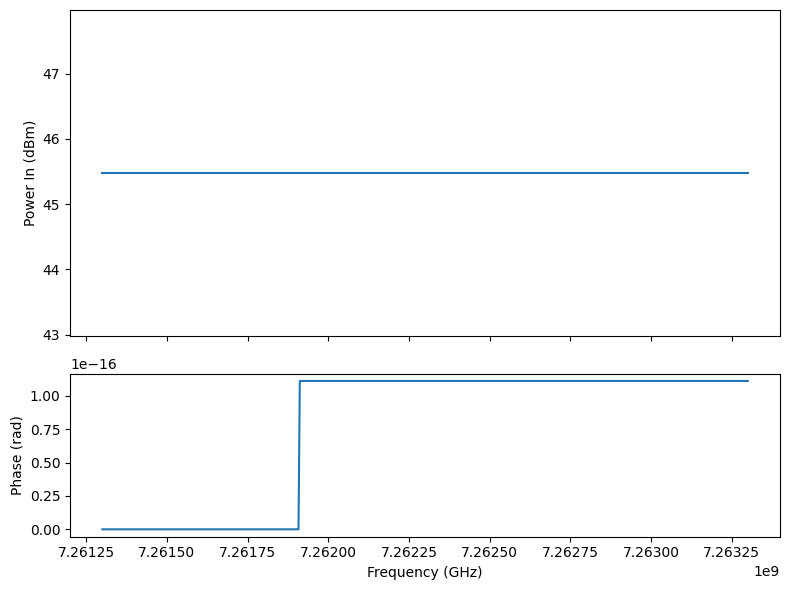

Frequency with minimum amplitude: 7.261300 GHz


In [12]:
def remove_linear_phase(freq, phase):
    coef = np.polyfit(freq, phase, 1)
    return phase - (coef[0] * freq + coef[1])

handle = "res_spec"
results = run_resonator_spec_twpa.get_data(handle)
axes = run_resonator_spec_twpa.acquired_results[handle].axis  

z = np.abs(results)  
lo_freqs = np.array(axes[0])   
sideband_freqs = np.array(axes[1])  

abs_freqs = lo_freqs[:, None] + sideband_freqs[None, :]  

flat_freqs = abs_freqs.flatten()
flat_amps = z.flatten()

# Sort for clean line plot
sort_idx = np.argsort(flat_freqs)
sorted_freqs = flat_freqs[sort_idx]
sorted_amps = flat_amps[sort_idx]

phase = np.angle(results)       # shape (5, 2001)
flat_phase = phase.flatten()    # flatten to 1D
sorted_phase = flat_phase[sort_idx]  # sort same as freq
unwrapped_phase = np.unwrap(sorted_phase)
phase_corr = remove_linear_phase(sorted_freqs, unwrapped_phase)


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), gridspec_kw={"height_ratios": [2, 1]}, sharex=True)

ax1.plot(sorted_freqs, 10*np.log10(sorted_amps**2/100)+30)
ax1.set_ylabel("Power In (dBm)")
ax2.plot(sorted_freqs, phase_corr, label="Corrected Phase")
ax2.set_xlabel("Frequency (GHz)")
ax2.set_ylabel("Phase (rad)")
plt.tight_layout()
plt.show()
min_amp_freq = sorted_freqs[np.argmin(sorted_amps)]
print(f"Frequency with minimum amplitude: {min_amp_freq/1e9:.6f} GHz")


## Resonator fit

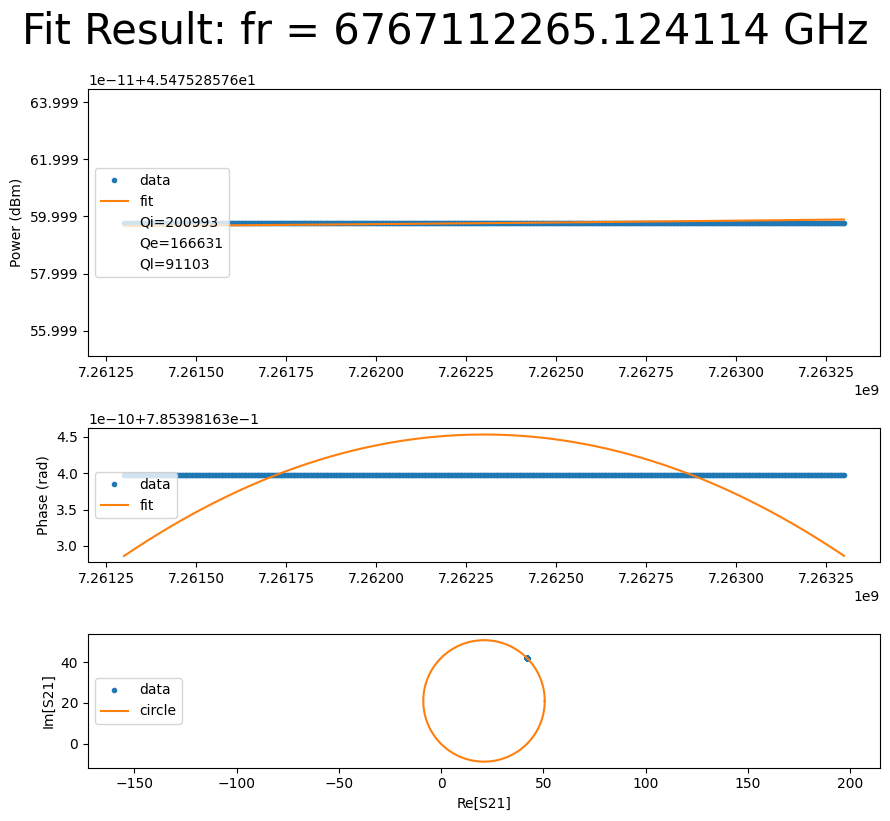

Fit: fr = 6767112265.124114 GHz, Qi = 200993, Qc = 166631, Ql = 91103
      Circle center = (20.99, 20.99), radius = 29.71


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- 1) Model from Baity et al. “Point redistribution…” Eq (1) ---
def s21_paper(f, fr, Ql, Qc_mag, phi, a, alpha, tau):
    background = a * np.exp(1j*alpha - 2j*np.pi*f*tau)
    numer = (Ql/Qc_mag) * np.exp(1j*phi)
    denom = 1 + 2j * Ql * (f/fr - 1)
    return background * (1 - numer / denom)

def s21_stack_paper(f, fr, Ql, Qc_mag, phi, a, alpha, tau):
    s21 = s21_paper(f, fr, Ql, Qc_mag, phi, a, alpha, tau).flatten()
    return np.concatenate([s21.real, s21.imag])

def circle_fit(z):
    x = z.real.flatten()
    y = z.imag.flatten()
    A = np.column_stack([x, y, np.ones_like(x)])
    b = -(x**2 + y**2)
    coeffs, *_ = np.linalg.lstsq(A, b, rcond=None)
    A_fit, B_fit, C_fit = coeffs
    xc = -A_fit / 2
    yc = -B_fit / 2
    r = np.sqrt(xc**2 + yc**2 - C_fit)
    return xc, yc, r

# --- 2) Load data ---
f_lo = np.array(axes[0])     # Local oscillator freq (GHz)
f_sb = np.array(axes[1])     # Sideband IF freq (GHz)
f_raw = (f_lo + f_sb).flatten()   # Total frequency (GHz)

z = results.flatten()        # complex S21, ensure 1D
amp_raw = np.abs(z)          # amplitude
phase = np.angle(z)          # phase

# --- 3) Reconstruct trace and prep fit ---
mag_db = 10 * np.log10((amp_raw**2) / 100) + 30
ydata = np.concatenate([z.real, z.imag])

# --- 4) Initial guesses ---
idx0 = np.argmin(amp_raw)
off_db = np.median(np.concatenate([mag_db[:10], mag_db[-10:]]))
a0 = np.sqrt(100 * 10**((off_db - 30) / 10))
p0 = [
    7.149e9,         # resonance frequency
    5e4,         # Ql
    5e4,         # Qc
    0.0,         # phi
    a0,          # a
    0.0,         # alpha
    0.0          # tau
]

# --- 5) Fit ---
popt, _ = curve_fit(
    s21_stack_paper,
    f_raw,
    ydata,
    p0=p0,
    maxfev=20000
)
fr_fit, Ql_fit, Qc_fit, phi_fit, a_fit, alpha_fit, tau_fit = popt
Qi_fit = 1.0 / (1.0/Ql_fit - 1.0/Qc_fit)

# --- 6) Circle fit ---
xc, yc, r = circle_fit(z)

# --- 7) Generate fit data ---
s21_fit = s21_paper(f_raw, *popt)
mag_fit = 10 * np.log10((np.abs(s21_fit)**2) / 100) + 30
phase_fit = np.angle(s21_fit)

# Flatten for plotting (if not already)
mag_db = mag_db.flatten()
phase = phase.flatten()
mag_fit = mag_fit.flatten()
phase_fit = phase_fit.flatten()

# --- 8) Plot ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(9, 8), gridspec_kw={"height_ratios": [2, 1, 1]})
fig.suptitle(f"Fit Result: fr = {fr_fit:.6f} GHz", fontsize=30, y=1.02)

ax1.plot(f_raw, mag_db, '.', label="data")
ax1.plot(f_raw, mag_fit, '-', label="fit")
ax1.plot([], [], " ", label=f"Qi={Qi_fit:.0f}")
ax1.plot([], [], " ", label=f"Qe={Qc_fit:.0f}")
ax1.plot([], [], " ", label=f"Ql={Ql_fit:.0f}")
ax1.set_ylabel("Power (dBm)")
ax1.legend(loc="center left")

ax2.plot(f_raw, phase, '.', label="data")
ax2.plot(f_raw, phase_fit, '-', label="fit")
ax2.set_ylabel("Phase (rad)")
ax2.legend(loc="center left")

ax3.plot(z.real, z.imag, '.', label="data")
θ = np.linspace(0, 2*np.pi, 200)
ax3.plot(xc + r*np.cos(θ), yc + r*np.sin(θ), '-', label="circle")
ax3.set_xlabel("Re[S21]")
ax3.set_ylabel("Im[S21]")
ax3.axis('equal')
ax3.legend(loc="center left")

plt.tight_layout(rect=[0, 0, 1, 1.03])
plt.show()

# --- 9) Print Results ---
print(f"Fit: fr = {fr_fit:.6f} GHz, Qi = {Qi_fit:.0f}, Qc = {Qc_fit:.0f}, Ql = {Ql_fit:.0f}")
print(f"      Circle center = ({xc:.4g}, {yc:.4g}), radius = {r:.4g}")


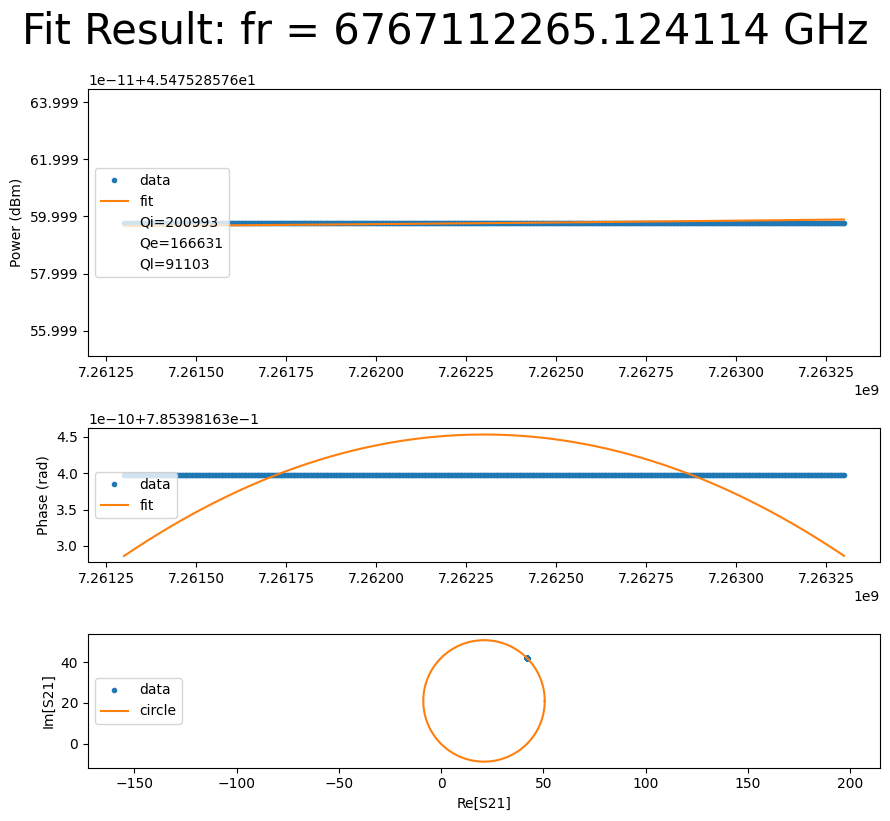

Fit: fr = 6767112265.124114 GHz, Qi = 200993, Qc = 166631, Ql = 91103
      Circle center = (20.99, 20.99), radius = 29.71


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- 1) Model from Baity et al. “Point redistribution…” Eq (1) ---
def s21_paper(f, fr, Ql, Qc_mag, phi, a, alpha, tau):
    background = a * np.exp(1j*alpha - 2j*np.pi*f*tau)
    numer = (Ql/Qc_mag) * np.exp(1j*phi)
    denom = 1 + 2j * Ql * (f/fr - 1)
    return background * (1 - numer / denom)

def s21_stack_paper(f, fr, Ql, Qc_mag, phi, a, alpha, tau):
    s21 = s21_paper(f, fr, Ql, Qc_mag, phi, a, alpha, tau).flatten()
    return np.concatenate([s21.real, s21.imag])

def circle_fit(z):
    x = z.real.flatten()
    y = z.imag.flatten()
    A = np.column_stack([x, y, np.ones_like(x)])
    b = -(x**2 + y**2)
    coeffs, *_ = np.linalg.lstsq(A, b, rcond=None)
    A_fit, B_fit, C_fit = coeffs
    xc = -A_fit / 2
    yc = -B_fit / 2
    r = np.sqrt(xc**2 + yc**2 - C_fit)
    return xc, yc, r

# --- 2) Load data ---
f_lo = np.array(axes[0])     # Local oscillator freq (GHz)
f_sb = np.array(axes[1])     # Sideband IF freq (GHz)
f_raw = (f_lo + f_sb).flatten()   # Total frequency (GHz)

z = results.flatten()        # complex S21, ensure 1D
amp_raw = np.abs(z)          # amplitude
phase = np.angle(z)          # phase

# --- 3) Reconstruct trace and prep fit ---
mag_db = 10 * np.log10((amp_raw**2) / 100) + 30
ydata = np.concatenate([z.real, z.imag])

# --- 4) Initial guesses ---
idx0 = np.argmin(amp_raw)
off_db = np.median(np.concatenate([mag_db[:10], mag_db[-10:]]))
a0 = np.sqrt(100 * 10**((off_db - 30) / 10))
p0 = [
    7.149e9,         # resonance frequency
    5e4,         # Ql
    5e4,         # Qc
    0.0,         # phi
    a0,          # a
    0.0,         # alpha
    0.0          # tau
]

# --- 5) Fit ---
popt, _ = curve_fit(
    s21_stack_paper,
    f_raw,
    ydata,
    p0=p0,
    maxfev=20000
)
fr_fit, Ql_fit, Qc_fit, phi_fit, a_fit, alpha_fit, tau_fit = popt
Qi_fit = 1.0 / (1.0/Ql_fit - 1.0/Qc_fit)

# --- 6) Circle fit ---
xc, yc, r = circle_fit(z)

# --- 7) Generate fit data ---
s21_fit = s21_paper(f_raw, *popt)
mag_fit = 10 * np.log10((np.abs(s21_fit)**2) / 100) + 30
phase_fit = np.angle(s21_fit)

# Flatten for plotting (if not already)
mag_db = mag_db.flatten()
phase = phase.flatten()
mag_fit = mag_fit.flatten()
phase_fit = phase_fit.flatten()

# --- 8) Plot ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(9, 8), gridspec_kw={"height_ratios": [2, 1, 1]})
fig.suptitle(f"Fit Result: fr = {fr_fit:.6f} GHz", fontsize=30, y=1.02)

ax1.plot(f_raw, mag_db, '.', label="data")
ax1.plot(f_raw, mag_fit, '-', label="fit")
ax1.plot([], [], " ", label=f"Qi={Qi_fit:.0f}")
ax1.plot([], [], " ", label=f"Qe={Qc_fit:.0f}")
ax1.plot([], [], " ", label=f"Ql={Ql_fit:.0f}")
ax1.set_ylabel("Power (dBm)")
ax1.legend(loc="center left")

ax2.plot(f_raw, phase, '.', label="data")
ax2.plot(f_raw, phase_fit, '-', label="fit")
ax2.set_ylabel("Phase (rad)")
ax2.legend(loc="center left")

ax3.plot(z.real, z.imag, '.', label="data")
θ = np.linspace(0, 2*np.pi, 200)
ax3.plot(xc + r*np.cos(θ), yc + r*np.sin(θ), '-', label="circle")
ax3.set_xlabel("Re[S21]")
ax3.set_ylabel("Im[S21]")
ax3.axis('equal')
ax3.legend(loc="center left")

plt.tight_layout(rect=[0, 0, 1, 1.03])
plt.show()

# --- 9) Print Results ---
print(f"Fit: fr = {fr_fit:.6f} GHz, Qi = {Qi_fit:.0f}, Qc = {Qc_fit:.0f}, Ql = {Ql_fit:.0f}")
print(f"      Circle center = ({xc:.4g}, {yc:.4g}), radius = {r:.4g}")
